In [2]:
#Load Dataset
import pandas as pd

df = pd.read_csv("adult.csv")

print(df.head(10))
print(df.shape)
print(df.columns)

   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-managerial   Not-in-family

In [3]:
#Handle missing values and encode categorical columns.
#Explain technique used (label encoding / one-hot encoding
import numpy as np
from sklearn.preprocessing import LabelEncoder

df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [4]:
#Define Target Variable
df['income'] = df['income'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop("income", axis=1)
y = df["income"]

In [5]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
#Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print(model.get_depth())
print(model.get_n_leaves())

40
3162


In [7]:
#Accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.8079345784064538


In [8]:
#Precision & Recall
from sklearn.metrics import precision_score, recall_score, f1_score

print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.6169676606467871
0.6400871459694989
0.6283147989734816


0.7525013822197191


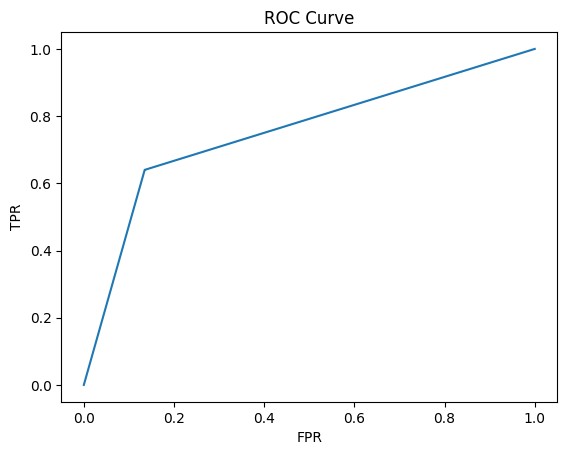

In [9]:
#ROC & AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [10]:
#K-Fold Cross-Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores.mean())
print(scores.std())

0.7654680754523859
0.02015654565876177


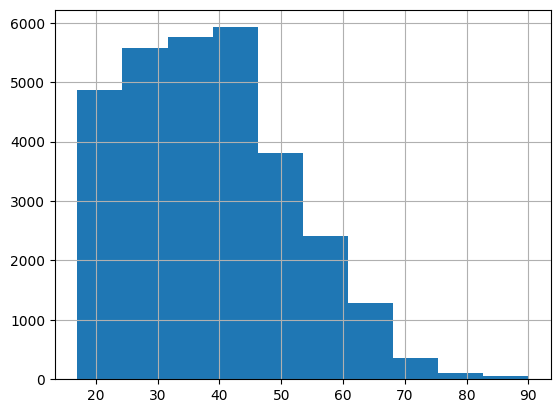

In [11]:
import matplotlib.pyplot as plt

df['age'].hist()
plt.show()

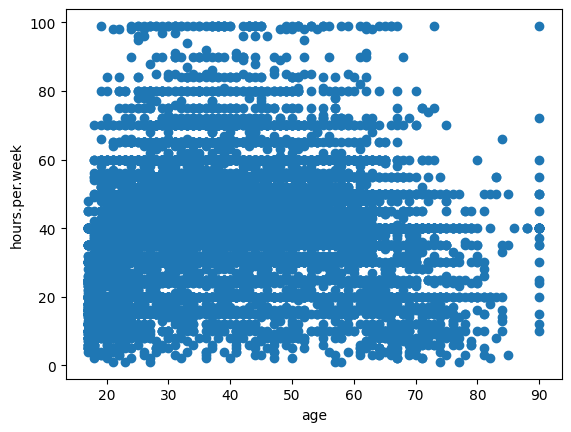

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df['age'], df['hours.per.week'])
plt.xlabel('age')
plt.ylabel('hours.per.week')
plt.show()

In [14]:
#Conclusion
#The Adult Census dataset was successfully analyzed using a Decision Tree model. After cleaning and encoding the data,
#the model achieved good accuracy with balanced precision and recall. ROC and AUC showed moderate performance, while
#cross-validation confirmed the model’s reliability. Overall, the model can reasonably predict income levels but
#can be further improved for better results.
